Using device: cpu
Пропуски в данных:
date      0
target    0
dtype: int64

Размер датасета: 4320
Диапазон дат: 2025-01-01 → 2025-06-29
Колонки: ['date', 'target']


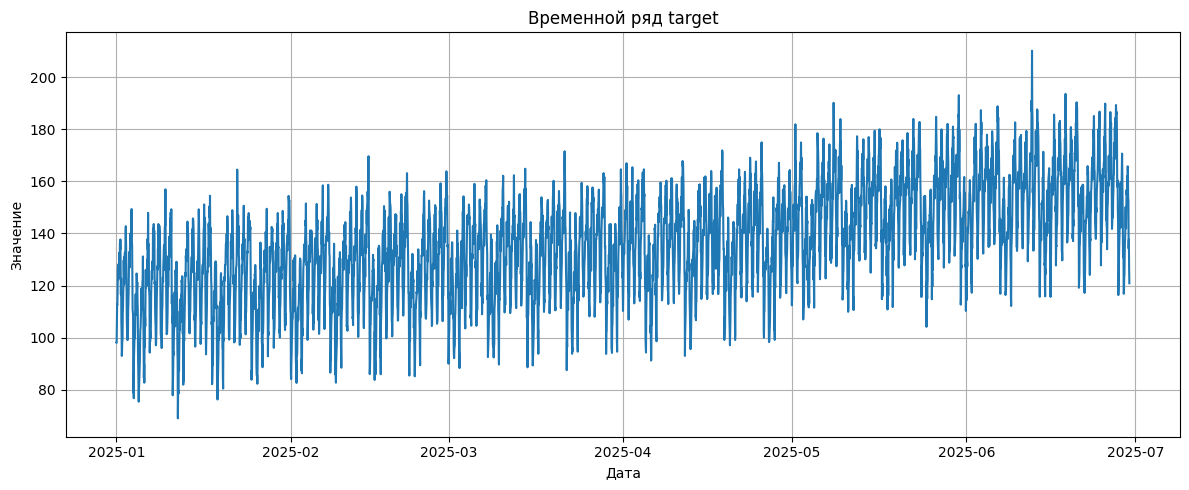

In [4]:
import os
import json
import random
import math
import warnings
from dataclasses import dataclass
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.grid'] = True

# Фиксация seed для воспроизводимости
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

df = pd.read_csv('S12-hw-dataset.csv')

# Преобразование даты и сортировка
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

# Проверка пропусков
print("Пропуски в данных:")
print(df.isnull().sum())

# Общая информация
print(f"\nРазмер датасета: {len(df)}")
print(f"Диапазон дат: {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Колонки: {df.columns.tolist()}")

# Базовый график ряда
fig, ax = plt.subplots()
ax.plot(df['date'], df['target'], linewidth=1.5)
ax.set_title('Временной ряд target')
ax.set_xlabel('Дата')
ax.set_ylabel('Значение')
plt.tight_layout()
plt.show()